Purpose: classify CO(GT) low/mid/high and forecast horizons; compare persistence, models without anomalies, and models with IF flags. Provide precision/recall table for h=1.

Load engineered data, build labels, and IF flags.

In [20]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score

artifacts = Path('artifacts')
fe_path = artifacts / 'feature_engineered.csv'
if not fe_path.exists():
    raise FileNotFoundError('Missing artifacts/feature_engineered.csv - run feature engineering first')

df = pd.read_csv(fe_path, parse_dates=['datetime']).sort_values('datetime').set_index('datetime')

iso_path = artifacts / 'isolation_forest_anomalies.csv'
if iso_path.exists():
    iso = pd.read_csv(iso_path, parse_dates=['timestamp'])
    iso['flag'] = 1
    iso_wide = iso.pivot_table(index='timestamp', columns='stream', values='flag', aggfunc='max')
    iso_wide = iso_wide.add_prefix('anom_iso_').reindex(df.index).fillna(0)
else:
    iso_wide = pd.DataFrame(index=df.index)

bins = [-np.inf, 1.5, 2.5, np.inf]
labels = ['low', 'mid', 'high']
df['CO_class'] = pd.cut(df['CO(GT)'], bins=bins, labels=labels)

horizons = [1, 6, 12, 24]
for h in horizons:
    df[f'CO_class_h{h}'] = df['CO_class'].shift(-h)

label_cols = [f'CO_class_h{h}' for h in horizons]
df = df.dropna(subset=['CO_class'] + label_cols)

feature_cols = [c for c in df.columns if c not in ['CO(GT)', 'CO_class'] + label_cols]
features_plus_iso = feature_cols + list(iso_wide.columns)


Chronological split helper.

In [21]:
def chronological_split(df, target_col, feature_cols, test_year=2005, val_ratio=0.15):
    train_val = df[df.index.year < test_year]
    test = df[df.index.year == test_year]
    n_val = int(len(train_val) * val_ratio)
    train = train_val.iloc[:-n_val] if n_val > 0 else train_val
    val = train_val.iloc[-n_val:] if n_val > 0 else pd.DataFrame()
    return {
        'X_train': train[feature_cols],
        'y_train': train[target_col],
        'X_val': val[feature_cols],
        'y_val': val[target_col] if len(val) else pd.Series(dtype='object'),
        'X_test': test[feature_cols],
        'y_test': test[target_col],
    }


Current-step models with/without IF flags; persistence baseline.

In [22]:
models = {
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(kernel='rbf', C=2.0, gamma='scale'),
}

splits_no = chronological_split(df[['CO_class'] + feature_cols], target_col='CO_class', feature_cols=feature_cols)
splits_yes = chronological_split(df[['CO_class'] + feature_cols].join(iso_wide), target_col='CO_class', feature_cols=features_plus_iso)

results_main = []

for variant, splits in [('No anomalies', splits_no), ('With IF flags', splits_yes)]:
    X_train_full = pd.concat([splits['X_train'], splits['X_val']], axis=0)
    y_train_full = pd.concat([splits['y_train'], splits['y_val']], axis=0)
    X_test = splits['X_test']
    y_test = splits['y_test']
    baseline_preds = df['CO_class'].shift(1).reindex(y_test.index)
    acc = accuracy_score(y_test, baseline_preds)
    results_main.append({'variant': variant, 'model': 'Persistence', 'split': 'test', 'accuracy': acc})

    for name, model in models.items():
        X_train_use = X_train_full.drop(columns=['CO_class']) if 'CO_class' in X_train_full.columns else X_train_full
        X_test_use = X_test.drop(columns=['CO_class']) if 'CO_class' in X_test.columns else X_test
        model.fit(X_train_use, y_train_full)
        preds = model.predict(X_test_use)
        acc = accuracy_score(y_test, preds)
        results_main.append({'variant': variant, 'model': name, 'split': 'test', 'accuracy': acc})

results_main_df = pd.DataFrame(results_main)
print(results_main_df)


         variant             model split  accuracy
0   No anomalies       Persistence  test  0.921727
1   No anomalies      RandomForest  test  0.942870
2   No anomalies  GradientBoosting  test  0.929825
3   No anomalies               SVM  test  0.958165
4  With IF flags       Persistence  test  0.921727
5  With IF flags      RandomForest  test  0.942420
6  With IF flags  GradientBoosting  test  0.925776
7  With IF flags               SVM  test  0.957715


Horizon forecasts (1/6/12/24) with/without IF flags; persistence baselines.

In [23]:
records = []

for h in horizons:
    target_col = f'CO_class_h{h}'
    splits_no = chronological_split(df[['CO_class'] + feature_cols + [target_col]], target_col=target_col, feature_cols=feature_cols)
    splits_yes = chronological_split(df[['CO_class'] + feature_cols + [target_col]].join(iso_wide), target_col=target_col, feature_cols=features_plus_iso)

    for variant, splits in [('No anomalies', splits_no), ('With IF flags', splits_yes)]:
        for split_name, X_split, y_split in [('val', splits['X_val'], splits['y_val']), ('test', splits['X_test'], splits['y_test'])]:
            baseline_preds = X_split['CO_class'] if 'CO_class' in X_split.columns else df.loc[y_split.index, 'CO_class']
            acc = accuracy_score(y_split, baseline_preds)
            records.append({'horizon': h, 'variant': variant, 'model': 'Persistence', 'split': split_name, 'accuracy': acc})

        X_train = splits['X_train'].drop(columns=['CO_class']) if 'CO_class' in splits['X_train'].columns else splits['X_train']
        X_val = splits['X_val'].drop(columns=['CO_class']) if 'CO_class' in splits['X_val'].columns else splits['X_val']
        X_test = splits['X_test'].drop(columns=['CO_class']) if 'CO_class' in splits['X_test'].columns else splits['X_test']

        for name, model in models.items():
            model.fit(X_train, splits['y_train'])
            for split_name, X_split, y_split in [('val', X_val, splits['y_val']), ('test', X_test, splits['y_test'])]:
                preds = model.predict(X_split)
                acc = accuracy_score(y_split, preds)
                records.append({'horizon': h, 'variant': variant, 'model': name, 'split': split_name, 'accuracy': acc})

cls_results = pd.DataFrame(records)
print(cls_results)


    horizon        variant             model split  accuracy
0         1   No anomalies       Persistence   val  0.871940
1         1   No anomalies       Persistence  test  0.921727
2         1   No anomalies      RandomForest   val  0.869115
3         1   No anomalies      RandomForest  test  0.931624
4         1   No anomalies  GradientBoosting   val  0.827684
..      ...            ...               ...   ...       ...
59       24  With IF flags      RandomForest  test  0.922627
60       24  With IF flags  GradientBoosting   val  0.737288
61       24  With IF flags  GradientBoosting  test  0.831309
62       24  With IF flags               SVM   val  0.822976
63       24  With IF flags               SVM  test  0.926226

[64 rows x 5 columns]


Precision/recall table on test for h=1 (persistence vs RandomForest, with/without IF flags).

In [19]:
# h=1 PR table
h = 1
splits_no = chronological_split(df[['CO_class'] + feature_cols + [f'CO_class_h{h}']], target_col=f'CO_class_h{h}', feature_cols=feature_cols)
splits_yes = chronological_split(df[['CO_class'] + feature_cols + [f'CO_class_h{h}']].join(iso_wide), target_col=f'CO_class_h{h}', feature_cols=features_plus_iso)

rf_no = RandomForestClassifier(n_estimators=200, random_state=42)
rf_yes = RandomForestClassifier(n_estimators=200, random_state=42)

X_train_no = splits_no['X_train'].drop(columns=['CO_class']) if 'CO_class' in splits_no['X_train'].columns else splits_no['X_train']
X_test_no = splits_no['X_test'].drop(columns=['CO_class']) if 'CO_class' in splits_no['X_test'].columns else splits_no['X_test']
X_train_yes = splits_yes['X_train'].drop(columns=['CO_class']) if 'CO_class' in splits_yes['X_train'].columns else splits_yes['X_train']
X_test_yes = splits_yes['X_test'].drop(columns=['CO_class']) if 'CO_class' in splits_yes['X_test'].columns else splits_yes['X_test']

y_train_no = splits_no['y_train']
y_train_yes = splits_yes['y_train']
y_test = splits_no['y_test']

rf_no.fit(X_train_no, y_train_no)
rf_yes.fit(X_train_yes, y_train_yes)

# Compute macro precision/recall
def pr(y_true, y_pred):
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    return prec, rec

baseline_preds = df['CO_class'].shift(1).reindex(y_test.index)
prec_base, rec_base = pr(y_test, baseline_preds)

pred_no = rf_no.predict(X_test_no)
prec_no, rec_no = pr(y_test, pred_no)

pred_yes = rf_yes.predict(X_test_yes)
prec_yes, rec_yes = pr(y_test, pred_yes)

pr_table = pd.DataFrame([
    {'variant': 'Persistence', 'precision': prec_base, 'recall': rec_base},
    {'variant': 'RF no IF flags', 'precision': prec_no, 'recall': rec_no},
    {'variant': 'RF with IF flags', 'precision': prec_yes, 'recall': rec_yes},
])
print(pr_table)


            variant  precision    recall
0       Persistence   0.440726  0.440726
1    RF no IF flags   0.573206  0.419990
2  RF with IF flags   0.616930  0.424217


Save metrics.

Visualize classification accuracies for main and horizon runs.

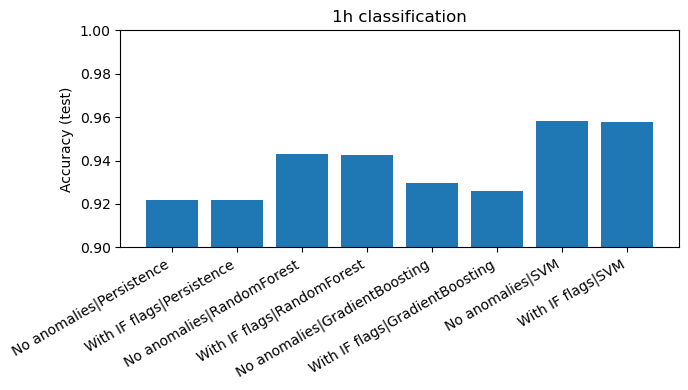

Horizon test accuracies (reformatted):
col      GradientBoosting (No IF)  GradientBoosting (IF)  \
horizon                                                    
1                        0.910481               0.911831   
6                        0.832659               0.828610   
12                       0.843905               0.846154   
24                       0.850652               0.831309   

col      RandomForest (No IF)  RandomForest (IF)  SVM (No IF)  SVM (IF)  \
horizon                                                                   
1                    0.931624           0.931174     0.932973  0.932524   
6                    0.923977           0.923077     0.926226  0.926226   
12                   0.926226           0.920828     0.926226  0.926226   
24                   0.923977           0.922627     0.926226  0.926226   

col      Persistence (No IF)  Persistence (IF)  
horizon                                         
1                   0.921727          0.921727  
6 

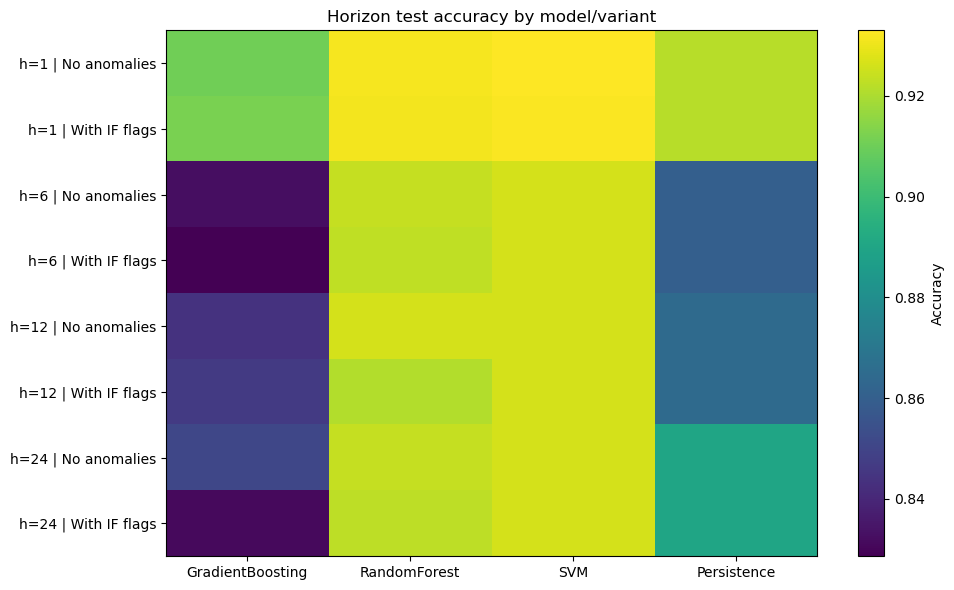

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

artifacts = Path('artifacts')
fig_dir = Path('figures')
fig_dir.mkdir(exist_ok=True)

# Main results
results_main_df.to_csv(artifacts / 'classification_metrics.csv', index=False)
cls_results.to_csv(artifacts / 'classification_horizon_metrics.csv', index=False)

# Bar plot for main test accuracy
main_test = results_main_df[results_main_df['split']=='test'].copy()
main_test['label'] = main_test['variant'] + '|' + main_test['model']
ordered_labels = []
unique_models = main_test['model'].unique()

for m in unique_models:
    if f'No anomalies|{m}' in main_test['label'].values:
        ordered_labels.append(f'No anomalies|{m}')
    if f'With IF flags|{m}' in main_test['label'].values:
        ordered_labels.append(f'With IF flags|{m}')
main_test = main_test.set_index('label').loc[ordered_labels].reset_index()

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(main_test['label'], main_test['accuracy'])

ax.set_ylabel('Accuracy (test)')
ax.set_title('1h classification')
ax.set_ylim(0.9, 1.0)

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
fig.savefig(fig_dir / 'classification_main_accuracy.png', dpi=150)
plt.show()


# # Heatmap-style plot for horizon accuracies (test)
# h_test = cls_results[cls_results['split']=='test']
# pivot = h_test.pivot_table(index=['horizon','variant'], columns='model', values='accuracy')

# # put Persistence last
# cols = list(pivot.columns)
# if 'Persistence' in cols:
#     cols.remove('Persistence')
#     cols.append('Persistence')
# pivot = pivot[cols]



# print('Horizon test accuracies:')
# print(pivot)
# fig, ax = plt.subplots(figsize=(10,6))
# im = ax.imshow(pivot.values, aspect='auto', cmap='viridis')
# ax.set_yticks(range(pivot.shape[0]))
# ax.set_yticklabels([f"h={idx[0]} | {idx[1]}" for idx in pivot.index])
# ax.set_xticks(range(len(pivot.columns)))
# ax.set_xticklabels(pivot.columns)
# fig.colorbar(im, ax=ax, label='Accuracy')
# ax.set_title('Horizon test accuracy by model/variant')
# plt.tight_layout()
# fig.savefig(fig_dir / 'classification_horizon_accuracy.png', dpi=150)
# plt.show()
# Heatmap-style plot for horizon accuracies (test)
h_test = cls_results[cls_results['split'] == 'test']

pivot = h_test.pivot_table(index=['horizon', 'variant'],
                           columns='model',
                           values='accuracy')

# put Persistence last
cols = list(pivot.columns)
if 'Persistence' in cols:
    cols.remove('Persistence')
    cols.append('Persistence')
pivot = pivot[cols]

# -------- 新增：只改表格输出的格式 --------
# 把 variant 改个短名字，并和 model 拼成列名
variant_map = {
    'No anomalies': 'No IF',
    'With IF flags': 'IF'
}

h_print = h_test.copy()
h_print['variant_short'] = h_print['variant'].map(variant_map).fillna(h_print['variant'])
h_print['col'] = h_print['model'] + ' (' + h_print['variant_short'] + ')'

table = h_print.pivot_table(index='horizon', columns='col', values='accuracy')

# 按你指定的列顺序排列
desired_cols = [
    'GradientBoosting (No IF)', 'GradientBoosting (IF)', 'RandomForest (No IF)', 'RandomForest (IF)',
    'SVM (No IF)', 'SVM (IF)',
    'Persistence (No IF)', 'Persistence (IF)',
]
# 只保留实际存在的列（以防有的模型没跑）
existing_cols = [c for c in desired_cols if c in table.columns]
table = table[existing_cols]

print('Horizon test accuracies (reformatted):')
print(table)
# -------- 表格部分到此为止 --------

# heatmap 代码保持不变，继续用原来的 pivot
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, aspect='auto', cmap='viridis')
ax.set_yticks(range(pivot.shape[0]))
ax.set_yticklabels([f"h={idx[0]} | {idx[1]}" for idx in pivot.index])
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
fig.colorbar(im, ax=ax, label='Accuracy')
ax.set_title('Horizon test accuracy by model/variant')
plt.tight_layout()
fig.savefig(fig_dir / 'classification_horizon_accuracy.png', dpi=150)
plt.show()


In [18]:
artifacts = Path('artifacts')
results_main_df.to_csv(artifacts / 'classification_metrics.csv', index=False)
cls_results.to_csv(artifacts / 'classification_horizon_metrics.csv', index=False)
pr_table.to_csv(artifacts / 'classification_pr_h1.csv', index=False)
print('Saved classification metrics and PR table to artifacts/')


NameError: name 'pr_table' is not defined